# Variance-driven placement on analytic targets

When each training point costs a simulation, you want every one of them to buy as much
information as possible. `astral-gp` picks the next point by asking the Gaussian process
where it is least certain, and sampling there.

This notebook shows the idea end to end on functions cheap enough to evaluate thousands of
times, so we can watch the posterior band collapse and check the placements against a
non-adaptive control. It runs in a few seconds and needs no data files.

**Contents**
1. The target
2. Starting from a coarse design
3. One step: where is the GP least sure?
4. Refining
5. Uncertainty against $N$
6. Where did the points go?
7. Two input dimensions
8. Diagnostic: when the fit goes degenerate

In [1]:
import warnings

import matplotlib.pyplot as plt
import numpy as np

from astral_gp import Astral

warnings.simplefilter('ignore')

plt.rcParams.update({'figure.dpi': 110, 'font.size': 11,
                     'axes.grid': True, 'grid.alpha': 0.25,
                     'axes.spines.top': False, 'axes.spines.right': False})

MEAN, BAND = '#0072B2', '#56B4E9'
SEED_C, ADDED_C = '#333333', '#D55E00'
RUNS, SEED = 'runs', 0

## 1. The target

A smooth oscillation on a linear trend. It has enough structure that where you sample
matters, and it is well behaved enough that the GP fit is stable — section 8 covers what
happens when it is not.

Note the signature: a simulator receives an `(n_samples, n_features)` array and returns
`(n_samples,)` or `(n_samples, n_outputs)`. That convention holds however many inputs and
outputs you have.

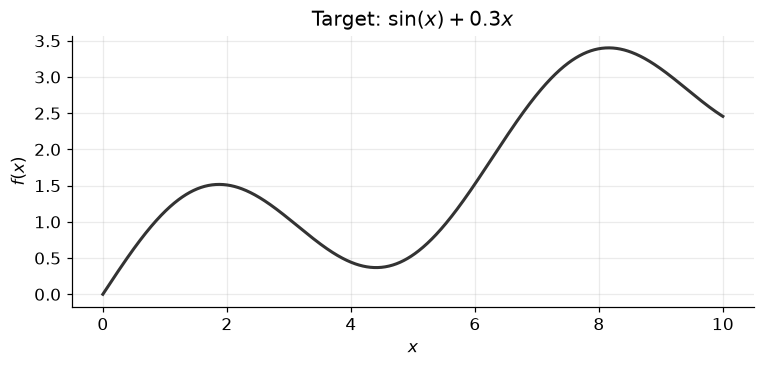

In [2]:
def target(X):
    """The expensive function we are pretending not to be able to afford."""
    return np.sin(X[:, 0]) + 0.3 * X[:, 0]


X_LO, X_HI = 0.0, 10.0
dense = np.linspace(X_LO, X_HI, 1000).reshape(-1, 1)

fig, ax = plt.subplots(figsize=(8, 3.2))
ax.plot(dense[:, 0], target(dense), color=SEED_C, lw=2)
ax.set_xlabel('$x$')
ax.set_ylabel('$f(x)$')
ax.set_title('Target: $\\sin(x) + 0.3x$')
plt.show()

## 2. Starting from a coarse design

Eight points spread across the domain — the kind of first pass you would run before knowing
where the interesting structure is.

In [3]:
N_INITIAL = 8

ast = Astral(test_name='analytic', runs_dir=RUNS, seed=SEED, verbose=False)
ast.build_initial_design([(X_LO, X_HI)], N_INITIAL, simulator=target)
ast.train_gp()

print(f'N = {len(ast.X)}, {ast.n_features} feature, {ast.n_outputs} output')
print(f'fitted kernel: {ast.gp.kernels_[0]}')
print(f'mean band width: {ast.mean_uncertainty():.6f}')

N = 8, 1 feature, 1 output
fitted kernel: WhiteKernel(noise_level=0.001) + 1.53**2 * RBF(length_scale=0.674)
mean band width: 0.174508


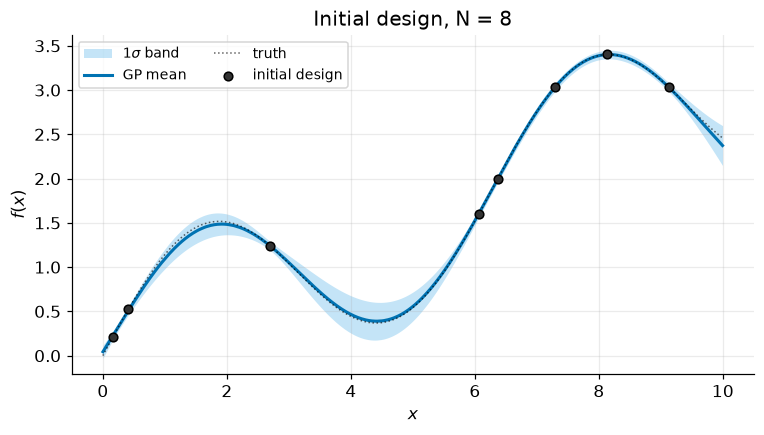

In [4]:
def plot_state(ast, ax, n_initial=N_INITIAL, title=None, show_truth=True):
    """Posterior band, training points, and the truth for reference.

    Candidates are drawn at random, so they need sorting before a line plot.
    """
    mean, lower, upper = ast.band_physical()
    x = ast.test_X_physical[:, 0]
    order = np.argsort(x)

    ax.fill_between(x[order], lower[order, 0], upper[order, 0], color=BAND,
                    alpha=0.35, lw=0, label=f'${ast.n_sigma:g}\\sigma$ band')
    ax.plot(x[order], mean[order, 0], color=MEAN, lw=2, label='GP mean')
    if show_truth:
        ax.plot(dense[:, 0], target(dense), color='k', lw=1, ls=':', alpha=0.6,
                label='truth')

    gx, gy = ast.X[:, 0], ast.y[:, 0]
    ax.scatter(gx[:n_initial], gy[:n_initial], color=SEED_C, edgecolor='k',
               s=32, zorder=3, label='initial design')
    if len(gx) > n_initial:
        ax.scatter(gx[n_initial:], gy[n_initial:], color=ADDED_C, edgecolor='k',
                   s=42, zorder=4, label='placed by GP')

    ax.set_title(title or f'N = {len(gx)}')
    return ax


fig, ax = plt.subplots(figsize=(8, 4))
plot_state(ast, ax, title=f'Initial design, N = {N_INITIAL}')
ax.set_xlabel('$x$'); ax.set_ylabel('$f(x)$')
ax.legend(loc='upper left', fontsize=9, ncol=2)
plt.show()

## 3. One step: where is the GP least sure?

The posterior standard deviation is largest where data is sparse or absent. Because a GP
has data on only one side of a domain edge, the first placements almost always go to the
boundaries.

Posterior variance does not depend on the observed $y$ values at all — only on *where* the
training points sit. Placement is a pure function of the design.

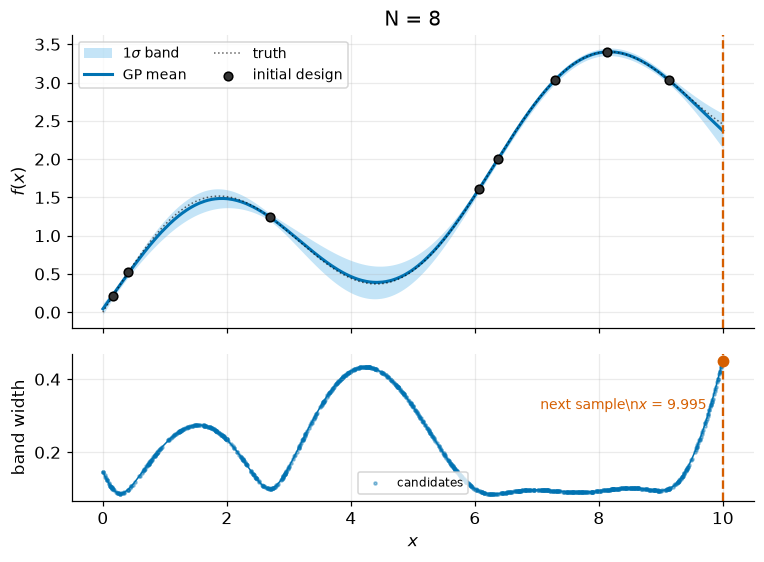

1000 candidates drawn; largest uncertainty at x = 9.9950


In [5]:
mean, lower, upper = ast.band_physical()
x = ast.test_X_physical[:, 0]
order = np.argsort(x)
width = (upper - lower)[:, 0]
x_next = ast.place_next()[0][0]

fig, (ax0, ax1) = plt.subplots(2, 1, figsize=(8, 5.5), sharex=True,
                               gridspec_kw={'height_ratios': [2, 1],
                                            'hspace': 0.12})
plot_state(ast, ax0, title='')
ax0.axvline(x_next, color=ADDED_C, ls='--', lw=1.5)
ax0.set_ylabel('$f(x)$')
ax0.legend(loc='upper left', fontsize=9, ncol=2)

#-- the candidates themselves, not a curve through them
ax1.scatter(x, width, s=4, color=MEAN, alpha=0.4, label='candidates')
ax1.plot(x[order], width[order], color=MEAN, lw=1)
ax1.axvline(x_next, color=ADDED_C, ls='--', lw=1.5)
ax1.scatter([x_next], [width.max()], color=ADDED_C, zorder=5, s=45)
ax1.annotate(f'next sample\\n$x$ = {x_next:.3f}', xy=(x_next, width.max()),
             xytext=(-10, -32), textcoords='offset points',
             ha='right', fontsize=9, color=ADDED_C)
ax1.set_xlabel('$x$'); ax1.set_ylabel('band width')
ax1.legend(fontsize=8, loc='lower center')
plt.show()

print(f'{ast.n_test} candidates drawn; largest uncertainty at x = {x_next:.4f}')

Those scattered dots are the candidate points. `astral-gp` does not evaluate the variance
on a grid — it draws `n_test` random points each step and takes the argmax over them. In one
dimension a grid would work just as well, but random sampling costs nothing as the number of
inputs grows, which is what section 7 relies on.

## 4. Refining

Thirty steps. At each one the GP is refit, fresh candidates are drawn, the argmax of the
posterior variance is found, the target is evaluated there, and the point is appended.

In [6]:
N_STEPS = 30
SNAPSHOTS = (8, 12, 20, 38)

ast = Astral(test_name='analytic', runs_dir=RUNS, seed=SEED, verbose=False)
ast.build_initial_design([(X_LO, X_HI)], N_INITIAL, simulator=target)

frames = {}
for _ in range(N_STEPS):
    ast.train_gp()
    if len(ast.X) in SNAPSHOTS:
        frames[len(ast.X)] = (ast.band_physical(), ast.test_X_physical[:, 0],
                              ast.X[:, 0].copy(), ast.y[:, 0].copy())
    ast.step(simulator=target)

ast.train_gp()
frames[len(ast.X)] = (ast.band_physical(), ast.test_X_physical[:, 0],
                      ast.X[:, 0].copy(), ast.y[:, 0].copy())

print(f'{N_INITIAL} -> {len(ast.X)} training points')
print(f"mean band width {ast.history['uncertainty'][0]:.4f} -> "
      f'{ast.mean_uncertainty():.4f}')

8 -> 38 training points
mean band width 0.1744 -> 0.0698


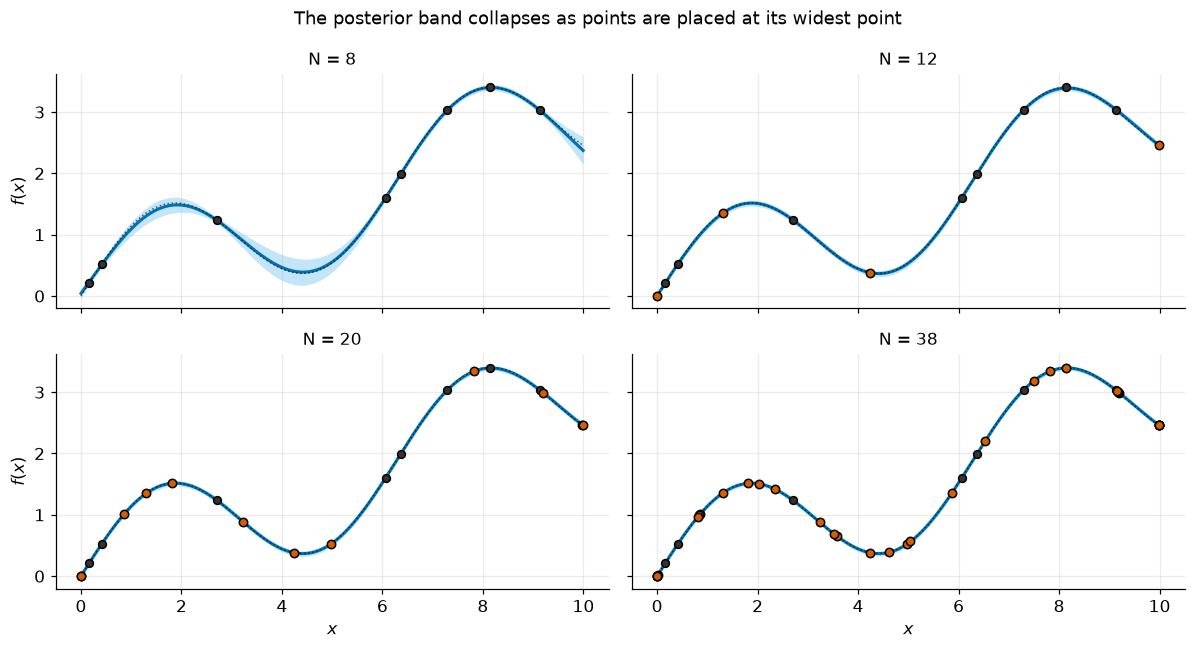

In [7]:
keys = sorted(frames)[:4]
fig, axes = plt.subplots(2, 2, figsize=(11, 6), sharex=True, sharey=True)

for ax, n in zip(axes.ravel(), keys):
    (mean, lower, upper), xt, gx, gy = frames[n]
    o = np.argsort(xt)
    ax.fill_between(xt[o], lower[o, 0], upper[o, 0], color=BAND, alpha=0.35, lw=0)
    ax.plot(xt[o], mean[o, 0], color=MEAN, lw=2)
    ax.plot(dense[:, 0], target(dense), color='k', lw=1, ls=':', alpha=0.6)
    ax.scatter(gx[:N_INITIAL], gy[:N_INITIAL], color=SEED_C, edgecolor='k', s=26,
               zorder=3)
    ax.scatter(gx[N_INITIAL:], gy[N_INITIAL:], color=ADDED_C, edgecolor='k', s=30,
               zorder=4)
    ax.set_title(f'N = {n}', fontsize=11)

for ax in axes[-1]:
    ax.set_xlabel('$x$')
for ax in axes[:, 0]:
    ax.set_ylabel('$f(x)$')

fig.suptitle('The posterior band collapses as points are placed at its widest point',
             fontsize=12)
fig.tight_layout()
plt.show()

## 5. Uncertainty against $N$

The headline number is the **mean posterior band width** over the candidate points. To judge
whether variance-driven placement is worth the bookkeeping, compare it against the obvious
alternative: a design of the same size that never looks at the GP at all.

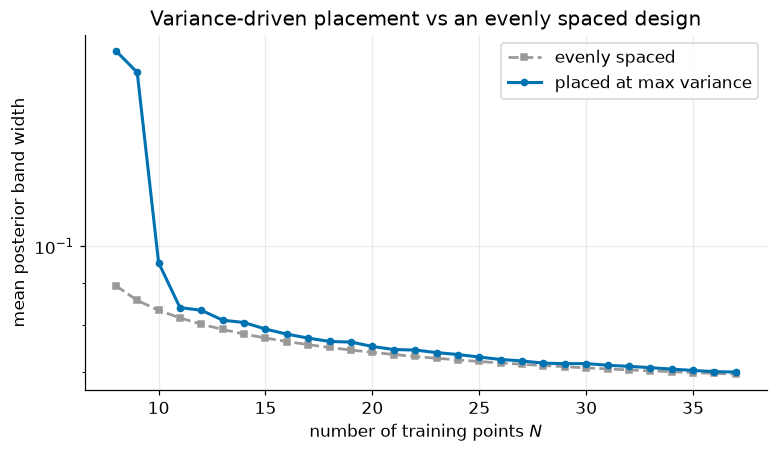

at N = 37:  astral 0.0699   evenly spaced 0.0695


In [8]:
def spread_uncertainty(n):
    """Mean band width for n evenly spaced points."""
    control = Astral(test_name='spread', runs_dir=RUNS, seed=SEED, verbose=False)
    grid = np.linspace(X_LO, X_HI, n).reshape(-1, 1)
    control.set_data(grid, target(grid))
    control.train_gp()
    return control.mean_uncertainty()


n_grid = np.array(ast.history['n'])
u_astral = np.array(ast.history['uncertainty'])
u_spread = np.array([spread_uncertainty(int(n)) for n in n_grid])

fig, ax = plt.subplots(figsize=(8, 4.2))
ax.plot(n_grid, u_spread, color='#999999', lw=1.8, ls='--', marker='s', ms=3.5,
        label='evenly spaced')
ax.plot(n_grid, u_astral, color=MEAN, lw=2, marker='o', ms=4,
        label='placed at max variance')
ax.set_xlabel('number of training points $N$')
ax.set_ylabel('mean posterior band width')
ax.set_yscale('log')
ax.legend()
ax.set_title('Variance-driven placement vs an evenly spaced design')
plt.show()

print(f'at N = {n_grid[-1]}:  astral {u_astral[-1]:.4f}   '
      f'evenly spaced {u_spread[-1]:.4f}')

Two honest caveats about that curve.

**It wobbles.** The kernel hyperparameters are refit from scratch at every step and the
candidates are redrawn, so the curve carries both real changes and Monte Carlo noise of order
$1/\\sqrt{N_\\mathrm{test}}$. Raising `n_test`, or pinning a fixed evaluation set with
`n_eval`, smooths it.

**An evenly spaced design is a strong baseline in 1-D.** With one input and a stationary
kernel, posterior variance depends only on distance to the nearest data, so spreading points
evenly is close to optimal already. Variance-driven placement earns its keep when the domain
has more dimensions than you can fill by brute force, when the response has structure
concentrated somewhere you cannot identify in advance, or when the campaign might stop at an
arbitrary $N$ and you want the best design so far.

## 6. Where did the points go?

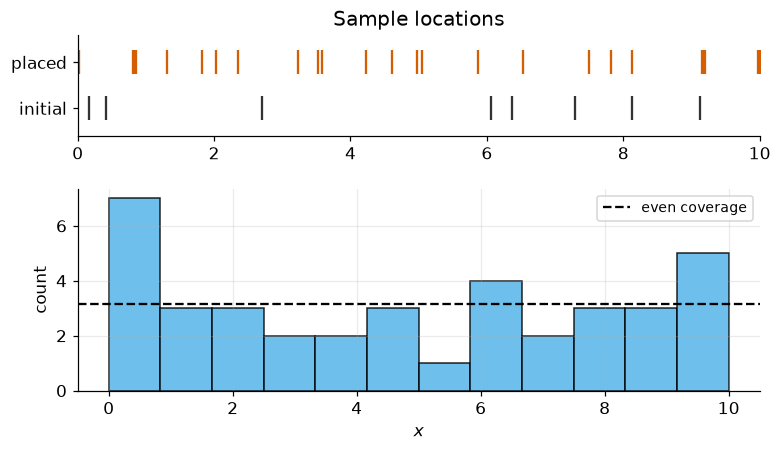

first six placements: [9.981e+00 4.231e+00 1.304e+00 4.000e-03 4.977e+00 9.994e+00]
-> the domain edges go first, then the widest interior gaps


In [9]:
added = ast.X[N_INITIAL:, 0]

fig, (ax0, ax1) = plt.subplots(2, 1, figsize=(8, 4.2),
                               gridspec_kw={'height_ratios': [1, 2],
                                            'hspace': 0.35})

ax0.scatter(ast.X[:N_INITIAL, 0], np.zeros(N_INITIAL), marker='|', s=260,
            color=SEED_C)
ax0.scatter(added, np.ones(len(added)), marker='|', s=260, color=ADDED_C)
ax0.set_yticks([0, 1]); ax0.set_yticklabels(['initial', 'placed'])
ax0.set_ylim(-0.6, 1.6); ax0.set_xlim(X_LO, X_HI); ax0.grid(False)
ax0.set_title('Sample locations')

ax1.hist(ast.X[:, 0], bins=12, range=(X_LO, X_HI), color=BAND, edgecolor='k',
         alpha=0.85)
ax1.axhline(len(ast.X) / 12, color='k', ls='--', lw=1.5,
            label='even coverage')
ax1.set_xlabel('$x$'); ax1.set_ylabel('count'); ax1.legend(fontsize=9)
plt.show()

first = np.array(ast.history['placement'][:6]).ravel()
print(f'first six placements: {np.round(first, 3)}')
print('-> the domain edges go first, then the widest interior gaps')

## 7. Two input dimensions

Nothing above was specific to one input. Here is the same loop on a 2-D target, which is
where random candidate sampling starts to matter: a grid dense enough to resolve two
dimensions costs the square of a 1-D grid, and the cube for three.

The target is a sum of two Gaussian bumps, so the structure sits in two specific places
rather than spread evenly — exactly the situation where sampling location should pay off.

In [10]:
def surface(X):
    """Two bumps on a tilted plane."""
    a = np.exp(-40.0 * ((X[:, 0] - 0.25) ** 2 + (X[:, 1] - 0.25) ** 2))
    b = np.exp(-25.0 * ((X[:, 0] - 0.75) ** 2 + (X[:, 1] - 0.7) ** 2))
    return 2.0 * a + 1.5 * b + 0.3 * X[:, 0]


N_INITIAL_2D, N_STEPS_2D = 12, 40

ast2 = Astral(test_name='analytic-2d', runs_dir=RUNS, seed=SEED, n_test=3000,
              verbose=False)
ast2.build_initial_design([(0.0, 1.0), (0.0, 1.0)], N_INITIAL_2D,
                          simulator=surface)
ast2.run_loop(N_STEPS_2D, simulator=surface)

u2 = ast2.history['uncertainty']
print(f'{N_INITIAL_2D} -> {len(ast2.X)} points in {ast2.n_features}-D')
print(f'mean band width {u2[0]:.4f} -> {ast2.mean_uncertainty():.4f} '
      f'({100 * ast2.mean_uncertainty() / u2[0]:.0f}% of initial)')

12 -> 52 points in 2-D
mean band width 0.8956 -> 0.1775 (20% of initial)


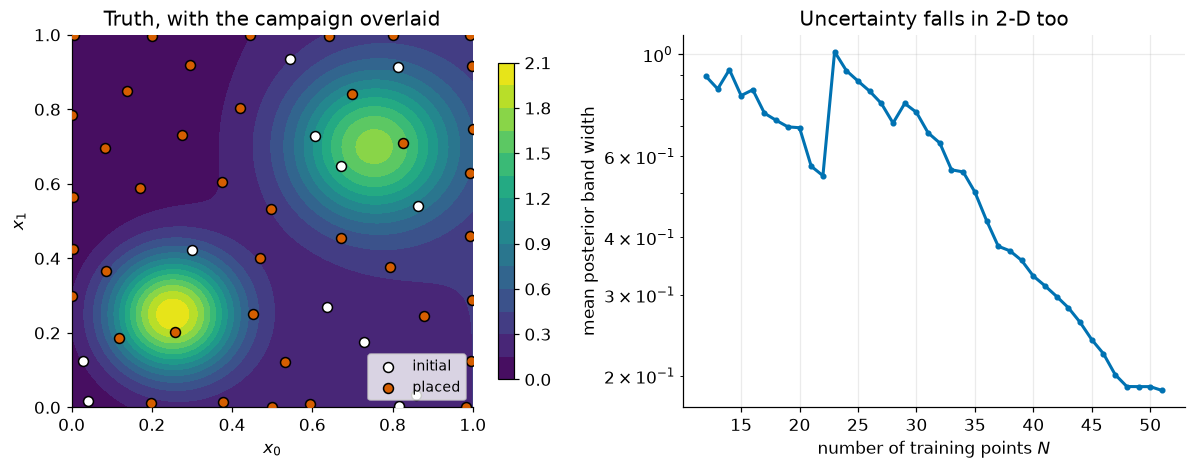

In [11]:
#-- Truth, and where the campaign actually sampled
gx, gy = np.meshgrid(np.linspace(0, 1, 160), np.linspace(0, 1, 160))
truth = surface(np.column_stack([gx.ravel(), gy.ravel()])).reshape(gx.shape)

fig, (ax0, ax1) = plt.subplots(1, 2, figsize=(11, 4.4))

im = ax0.contourf(gx, gy, truth, levels=18, cmap='viridis')
ax0.scatter(ast2.X[:N_INITIAL_2D, 0], ast2.X[:N_INITIAL_2D, 1], color='w',
            edgecolor='k', s=42, zorder=3, label='initial')
ax0.scatter(ast2.X[N_INITIAL_2D:, 0], ast2.X[N_INITIAL_2D:, 1], color=ADDED_C,
            edgecolor='k', s=42, zorder=4, label='placed')
ax0.set_xlabel('$x_0$'); ax0.set_ylabel('$x_1$')
ax0.set_title('Truth, with the campaign overlaid')
ax0.legend(fontsize=9, loc='lower right')
ax0.grid(False)
fig.colorbar(im, ax=ax0, shrink=0.85)

ax1.plot(ast2.history['n'], u2, color=MEAN, lw=2, marker='o', ms=3)
ax1.set_xlabel('number of training points $N$')
ax1.set_ylabel('mean posterior band width')
ax1.set_yscale('log')
ax1.set_title('Uncertainty falls in 2-D too')
plt.tight_layout()
plt.show()

The placements spread across the square rather than piling onto the bumps. That is worth
understanding rather than being disappointed by: **posterior variance is high where data is
absent, not where the function is interesting.** Maximum-variance placement is a space-filling
rule that adapts to the fitted length scale; it is not chasing features. If you want to
concentrate on a response's structure you need an acquisition that looks at $y$ — which this
one deliberately does not.

What it does give you is a design that is sensible at *every* $N$, in a space where you could
not have afforded a grid.

A one-feature slice through the fitted surrogate:

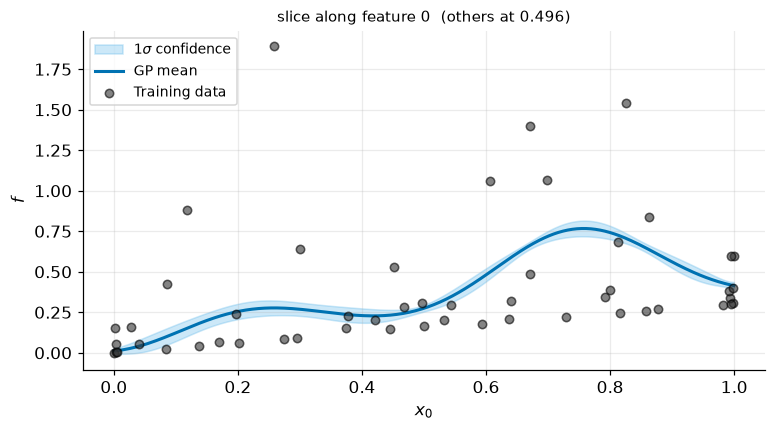

In [12]:
from astral_gp.plotting import plot_slice

fig, ax = plt.subplots(figsize=(8, 4))
plot_slice(ast2, feature=0, xlabel='$x_0$', ylabel='$f$', ax=ax)
plt.show()

## 8. Diagnostic: when the fit goes degenerate

One failure mode is worth being able to recognise. The GP hyperparameters are refit at every
step by L-BFGS from a small number of starts, and the marginal likelihood is multimodal: as
well as the sensible fit there is usually a degenerate one with a very short length scale and
a large noise term, which explains the data as pure noise.

If the optimiser lands there, every candidate becomes decorrelated from every training point,
the GP falls back to predicting its prior, and the reported uncertainty jumps by an order of
magnitude for that one step.

`astral-gp` guards against this two ways: the length scale is floored at `1e-2` on whitened
inputs, so the mode cannot run away to zero, and `n_restarts=2` gives the optimiser more than
one chance to find the good basin. Neither is a guarantee. Here is the failure on a steep
target with the guards turned off:

In [13]:
def forrester(X):
    return (6.0 * X[:, 0] - 2.0) ** 2 * np.sin(12.0 * X[:, 0] - 4.0)


def watch(n_restarts, steps=9):
    """Run a short campaign, reporting the fitted length scale each step."""
    a = Astral(test_name='steep', runs_dir=RUNS, seed=SEED, verbose=False,
               n_restarts=n_restarts)
    a.build_initial_design([(0.0, 1.0)], 8, simulator=forrester)
    rows = []
    for _ in range(steps):
        a.train_gp()
        noise, _, ell = a.gp.hyperparameters[0]
        ell = float(np.atleast_1d(ell)[0])
        rows.append((len(a.X), a.mean_uncertainty(), ell, noise))
        a.step(simulator=forrester)
    return rows


for label, nr in [('n_restarts=0  (guard off)', 0), ('n_restarts=2  (default)', 2)]:
    print(f'\n{label}')
    print(f"  {'N':>4} {'uncertainty':>12} {'length scale':>13} {'noise':>9}")
    for n, u, ell, noise in watch(nr):
        flag = '  <-- DEGENERATE' if ell <= 1.05e-2 else ''
        print(f'  {n:>4} {u:>12.4f} {ell:>13.6f} {noise:>9.4f}{flag}')


n_restarts=0  (guard off)
     N  uncertainty  length scale     noise
     8       0.8980      0.242331    0.0010
     9       0.7313      0.239822    0.0010
    10       0.4720      0.265178    0.0010
    11       1.9982      0.010000    0.8297  <-- DEGENERATE
    12       0.1017      0.458822    0.0010
    13       0.0891      0.490115    0.0010
    14       0.0878      0.473952    0.0010
    15       0.0843      0.495100    0.0010
    16       0.0830      0.462570    0.0010

n_restarts=2  (default)
     N  uncertainty  length scale     noise
     8       0.8980      0.242331    0.0010
     9       0.7313      0.239821    0.0010
    10       0.4720      0.265178    0.0010
    11       0.1055      0.459279    0.0010
    12       0.0907      0.494087    0.0010
    13       0.0898      0.470926    0.0010
    14       0.0859      0.493045    0.0010
    15       0.0840      0.491806    0.0010
    16       0.0829      0.459893    0.0010


The signature is unmistakable once you know it: the fitted length scale sits on its lower
bound, the noise level jumps, and the uncertainty spikes for one step before recovering.

A check you can run inside your own loop:

In [14]:
def is_degenerate(ast, output=0, floor=1e-2, tol=1.05):
    """True when the fitted length scale has pinned to its lower bound."""
    ell = float(np.atleast_1d(ast.gp.hyperparameters[output][2])[0])
    return ell <= floor * tol


smooth = Astral(test_name='check', runs_dir=RUNS, seed=SEED, verbose=False)
smooth.build_initial_design([(X_LO, X_HI)], 20, simulator=target)
smooth.train_gp()

print(f'degenerate on the smooth target? {is_degenerate(smooth)}')
print(f'its length scale: '
      f'{float(np.atleast_1d(smooth.gp.hyperparameters[0][2])[0]):.4f}')

degenerate on the smooth target? False
its length scale: 0.7877


## Summary

- Posterior variance depends only on **where** the training points are, not on the values
  observed there, so placement is a property of the design alone.
- The first placements go to the **domain edges**, then fill the widest interior gaps.
- Candidates are drawn at **random**, not on a grid, which is what lets the same loop run
  unchanged in two dimensions and beyond.
- Maximum-variance placement is a **space-filling** rule that adapts to the fitted length
  scale. It does not chase features in the response, because it never looks at $y$.
- In 1-D an evenly spaced design is a strong baseline. The method pays off in higher
  dimensions and whenever the campaign may stop early.
- Watch for a **degenerate fit** on steep targets; `is_degenerate()` above catches it.

Notebooks 2 and 3 apply the same loop to a real dataset of stellar explosion simulations,
first with one output and then with three.